In [164]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
import torchaudio
import torchvision
import torchtext
import torch.nn as nn
import pandas as pd
import jupyterlab as jlab
import matplotlib as mpl
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import datasets, transforms
from torchvision.transforms import v2, ToPILImage, ToTensor
from torchvision.utils import save_image
from torchaudio.transforms import Spectrogram, Resample
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import vocab

from PIL import Image

from collections import OrderedDict
from typing import List, Dict, Optional

from dataclasses import dataclass, field

In [165]:

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.CIFAR10(root="./data", train = True, download = True, transform = transform) 

Files already downloaded and verified


In [166]:
batch_size = 4
data_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

images, labels = next(iter(data_loader))
print("Форма батча изображений:", images.shape) 
print("Метки батча:", labels)

Форма батча изображений: torch.Size([4, 3, 128, 128])
Метки батча: tensor([8, 9, 7, 2])


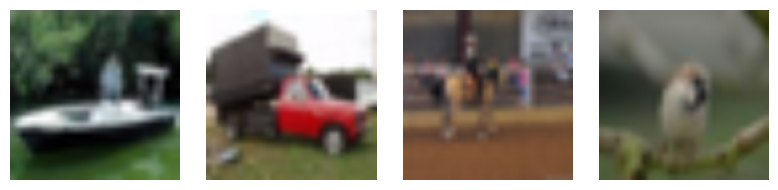

In [167]:
def show_images(images, cols=4):
    """
    Display a grid of images with labels.
    images: torch.Tensor of shape [N, C, H, W] (values in [0,1])
    """
    rows = (batch_size + cols - 1) // cols  # Calculate rows needed
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if batch_size > 1 else [axes]
    
    for i in range(batch_size):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        
        axes[i].imshow(img)
        axes[i].axis('off')

    for i in range(batch_size, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


show_images(images, cols=4)

### ColorJitter

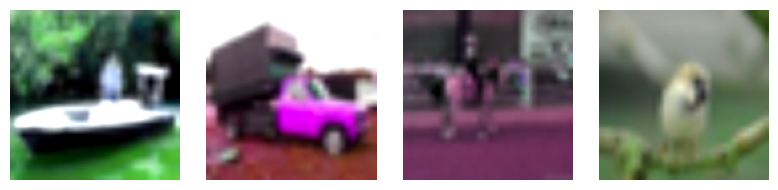

In [168]:
def apply_jitter_show(images, brightness=0.6, contrast=0.6, saturation=0.6, hue=0.2, cols=4):
    jitter = v2.ColorJitter(
        brightness=brightness,  
        contrast=contrast,    
        saturation=saturation,  
        hue= hue      
    )
    rows = (batch_size + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if batch_size > 1 else [axes]
    
    for i in range(batch_size):
        jitt_img = jitter(images[i])
        img = jitt_img.permute(1, 2, 0).cpu().numpy()
        
        axes[i].imshow(img)
        axes[i].axis('off')

    for i in range(batch_size, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
        
apply_jitter_show(images)

hue -- параметр который на круге цветов сдвигает все цвета на одну величину 

изменение яркости, контрастности, насыщенности и цвета не влияет на суть объектов на фото, собака остается собакой, машина машиной, объекты остаются различимыми,

но из-за того что меняются цвета, картинка может стать неправдоподобной,

поэтому нужно быть осторожным с аугментацией данных при помощи ColorJitter, если мы хотим обращать внимание на цвет объектов на картинках

### FiveCrop

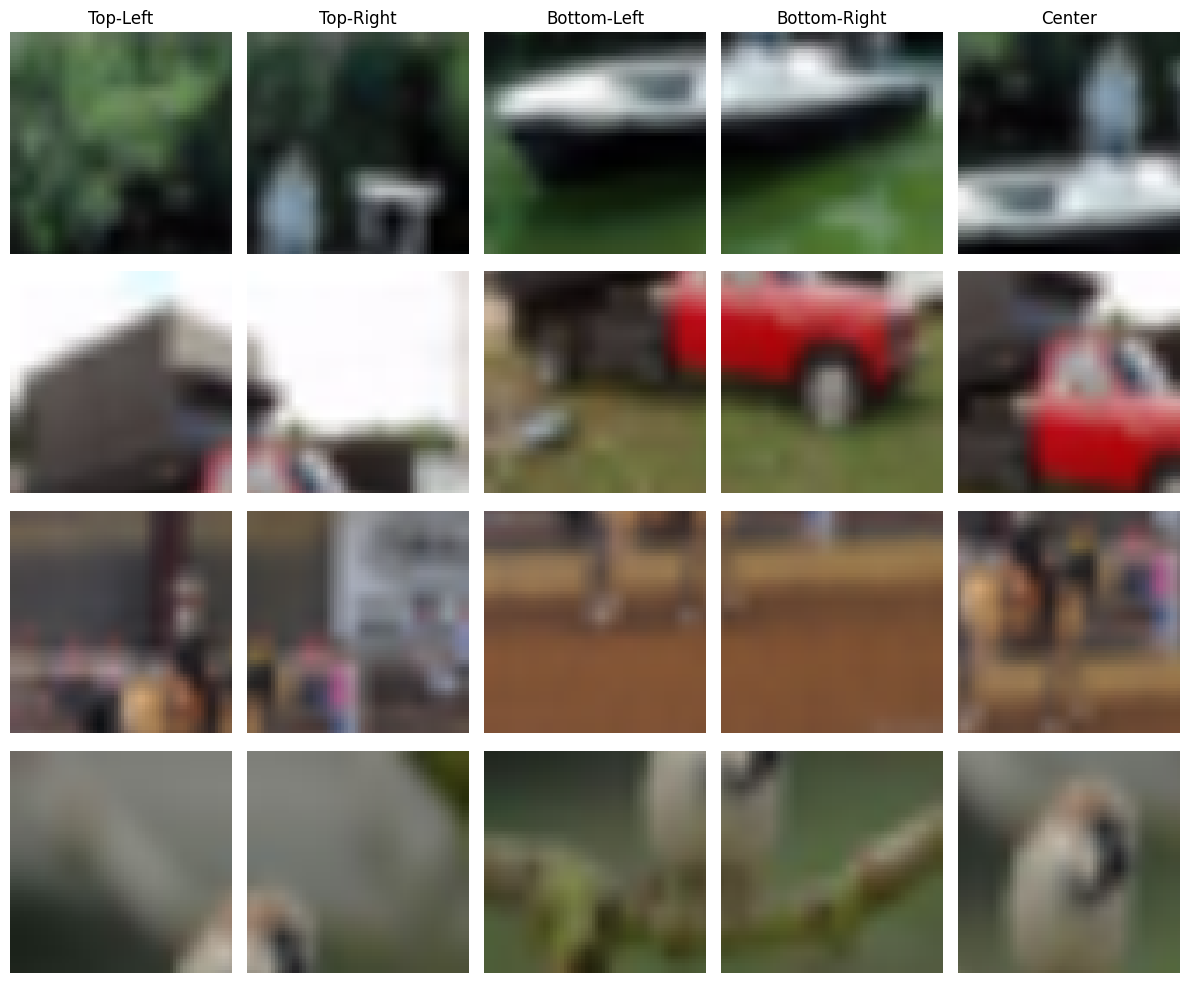

In [169]:
def five_crop_and_show(images, size=16):
    B = images.shape[0]
    total_crops = B * 5 
    
    fig, axes = plt.subplots(B, 5, figsize=(12, 2.5 * B))

    # Define transforms
    to_pil = ToPILImage()
    five_crop = v2.FiveCrop(size)
    to_tensor = ToTensor()  # Optional: if you need tensors later

    crop_names = ['Top-Left', 'Top-Right', 'Bottom-Left', 'Bottom-Right', 'Center']

    for i in range(B):
        # Convert tensor to PIL (required by FiveCrop)
        img_pil = to_pil(images[i].cpu())
        
        # Apply FiveCrop → tuple of 5 PIL images
        crops = five_crop(img_pil)
        
        for j, crop in enumerate(crops):
            # Convert back to numpy for imshow
            crop_np = np.array(crop)  # PIL → numpy (H, W, C)
            axes[i, j].imshow(crop_np)
            if i == 0:  # Only set column titles on first row
                axes[i, j].set_title(crop_names[j])
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()
five_crop_and_show(images, 64)

при таком кропе мы акцентируем внимание на том что находится в конкретной части картинки, но при этом если выставлять большой размер кропа сам объект остается узнаваемым

это может быть полезно, если бОльшая часть картинки является шумом а главный объект занимает немного пространства

но иногда после кропа на картинке больше не видно объекта или видно но его не получается различить, поэтому нужно подбирать размер кропа исходя из того что мы хотим 

### ElasticTransform

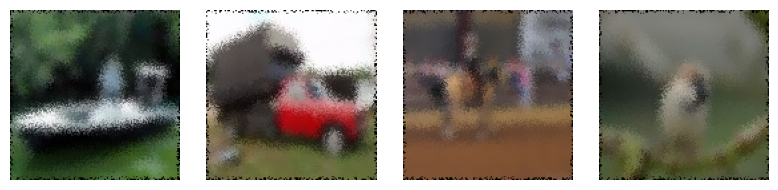

In [170]:
def apply_elastic_transform_show(images, alpha=5, sigma=0.1, cols=4):
    affine = v2.ElasticTransform(alpha=alpha, sigma=sigma)

    rows = (batch_size + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if batch_size > 1 else [axes]
    
    for i in range(batch_size):
        elastic_img = affine(images[i])
        img = elastic_img.permute(1, 2, 0).cpu().numpy()
        
        axes[i].imshow(img)
        axes[i].axis('off')

    for i in range(batch_size, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
        
apply_elastic_transform_show(images)

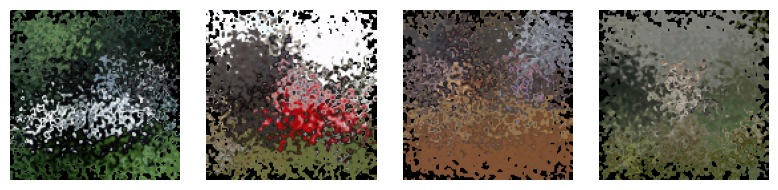

In [171]:
apply_elastic_transform_show(images, alpha=100, sigma=1)

добавляет шума в картинку, объекты остаются различимыми, но если поиграться с параметрами то объекты перестают быть похожими на себя

это можно использовать для обучения моделей понимать какой объект находится на фото при сильном шуме

### RandomHorizontalFlip

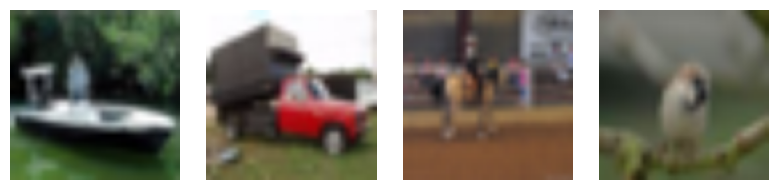

In [172]:
def apply_horizontal_flip_show(images, cols=4):
    horiz_flip = v2.RandomHorizontalFlip(p=0.5)

    rows = (batch_size + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if batch_size > 1 else [axes]
    
    for i in range(batch_size):
        flip_img = horiz_flip(images[i])
        img = flip_img.permute(1, 2, 0).cpu().numpy()
        
        axes[i].imshow(img)
        axes[i].axis('off')

    for i in range(batch_size, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
        
apply_horizontal_flip_show(images)

так как почти все объекты в природе симметричные это преобразование не ухудшает нашу выборку и превносит некоторе разнообразие

### GaussianBlur

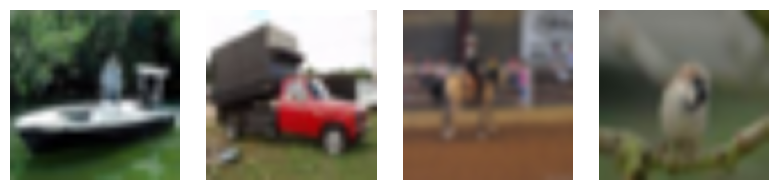

In [173]:
def apply_gauss_blur_show(images, kernel_size=15, cols=4):
    gauss_blur = v2.GaussianBlur(kernel_size=kernel_size)

    rows = (batch_size + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if batch_size > 1 else [axes]
    
    for i in range(batch_size):
        blured_img = gauss_blur(images[i])
        img = blured_img.permute(1, 2, 0).cpu().numpy()
        
        axes[i].imshow(img)
        axes[i].axis('off')

    for i in range(batch_size, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
        
apply_gauss_blur_show(images, 25)

GaussianBlur сглаживает переходы между разными цветами -- берет матрицу из нескольких соседних пикселей, kernel_size задает сколько соседей будет учитываться при пересчете и вместо центрального пишет среднее значение в этой матрице

это может быть полезно для удаления лишних мелких деталей с сохранением размера картинки